# Salary Prediction

<img src='https://londonincmagazine.ca/wp-content/uploads/2025/07/Remuneration-Main.jpg'>

🇹🇷 Türkçe
Bu projenin amacı, çeşitli makine öğrenmesi ve derin öğrenme algoritmalarını kullanarak çalışan maaşlarını yüksek doğrulukla tahmin eden bir model geliştirmektir.

🇬🇧 English
The goal of this project is to develop a model that predicts employee salaries with high accuracy using various machine learning and deep learning algorithms.

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

# Deep Learning imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense

In [2]:
df=pd.read_csv('Salary_Data.csv') 

In [3]:
#EDA

In [4]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [5]:
df.tail()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0
6703,26.0,Female,High School,Sales Executive,1.0,35000.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [7]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [8]:
df = df.dropna(subset=['Salary', 'Years of Experience', 'Job Title', 'Education Level', 'Gender','Age'])

In [9]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [10]:
df.describe()

,Age,Years of Experience,Salary
count,6698.000000,6698.000000,6698.000000
mean,33.623022,8.095178,115329.253061
std,7.615784,6.060291,52789.792507
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [11]:
df.Gender.value_counts()

Gender
Male      3671
Female    3013
Other       14
Name: count, dtype: int64

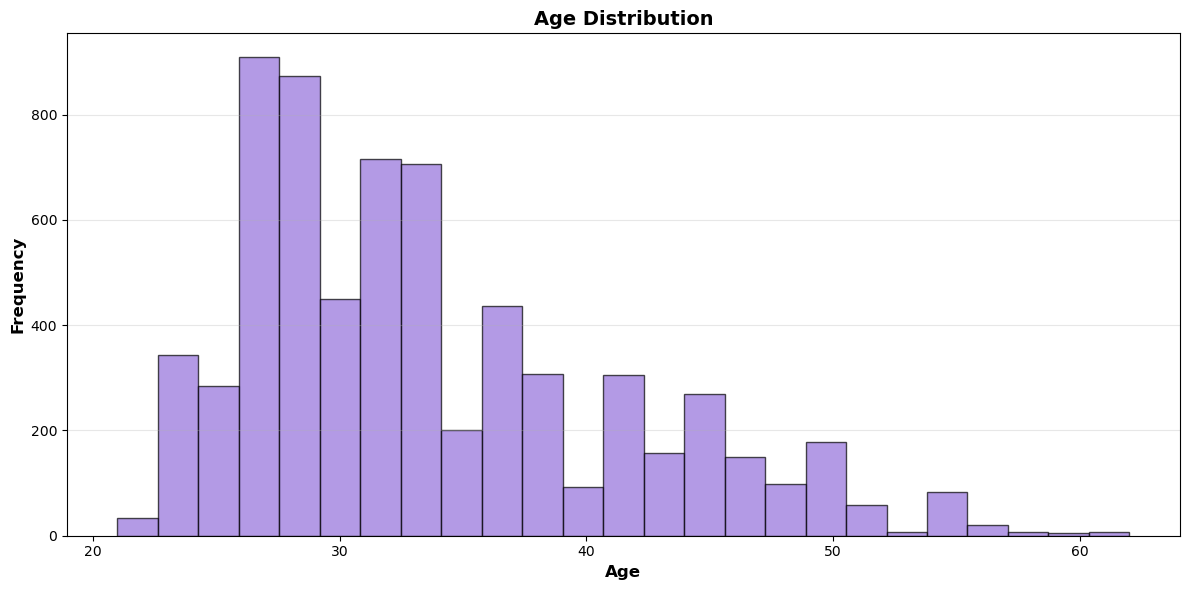

In [12]:
# Age Distribution
plt.figure(figsize=(12, 6))
plt.hist(df['Age'], bins=25, color='mediumpurple', edgecolor='black', alpha=0.7)
plt.title('Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

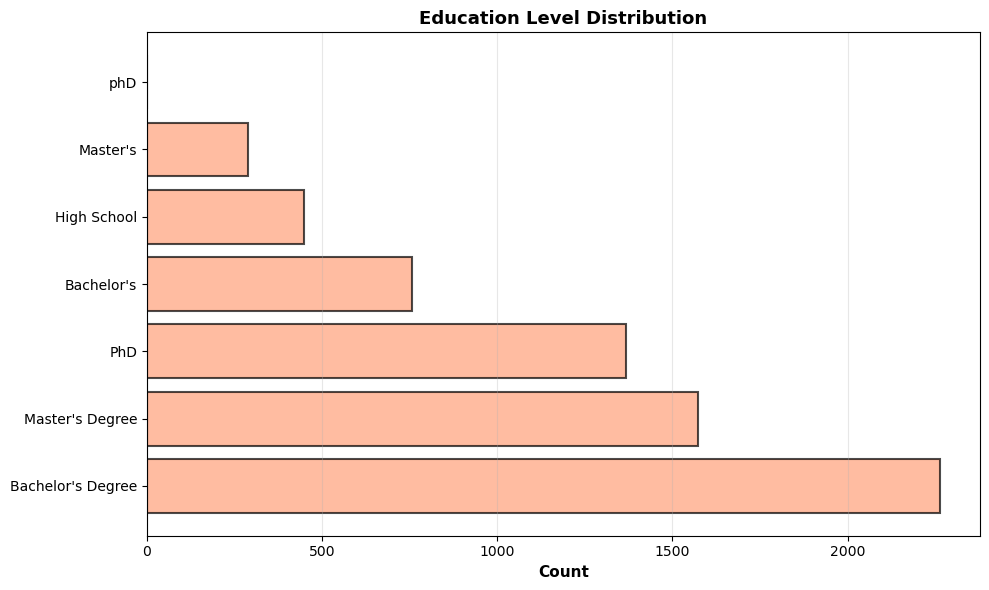

In [13]:
# Education Level Distribution
plt.figure(figsize=(10, 6))
edu_counts = df['Education Level'].value_counts()
plt.barh(edu_counts.index, edu_counts.values, color='#FFA07A', edgecolor='black', linewidth=1.5, alpha=0.7)
plt.title('Education Level Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Count', fontsize=11, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

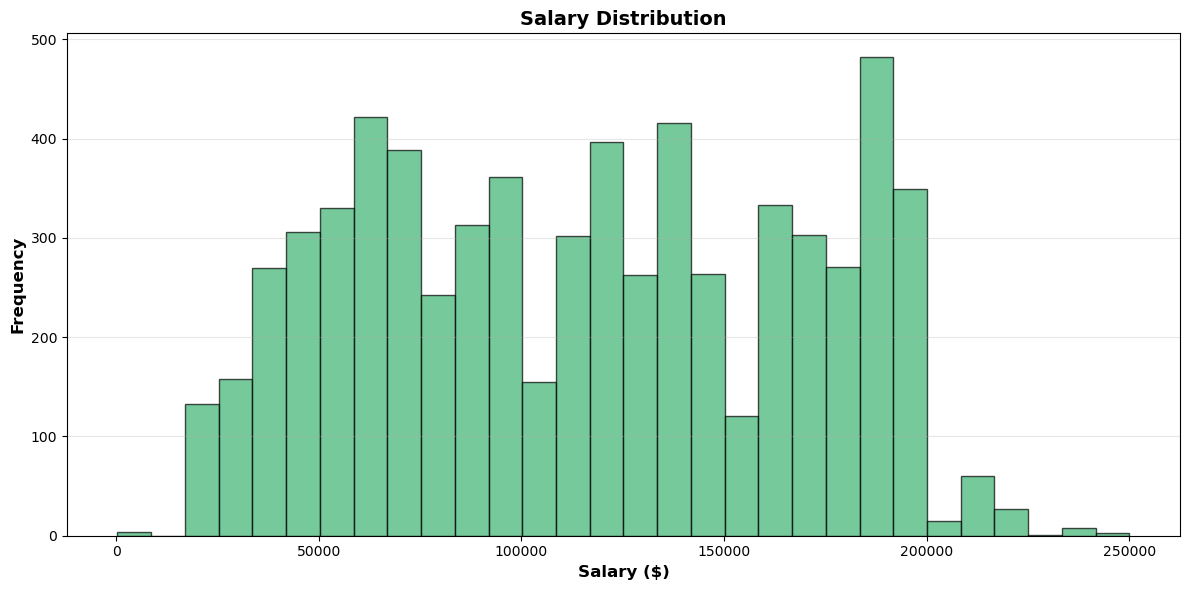

In [14]:
#Salary
plt.figure(figsize=(12, 6))
plt.hist(df['Salary'], bins=30, color='mediumseagreen', edgecolor='black', alpha=0.7)
plt.title('Salary Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Salary ($)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

In [15]:
df['Years of Experience'].describe()

count    6698.000000
mean        8.095178
std         6.060291
min         0.000000
25%         3.000000
50%         7.000000
75%        12.000000
max        34.000000
Name: Years of Experience, dtype: float64

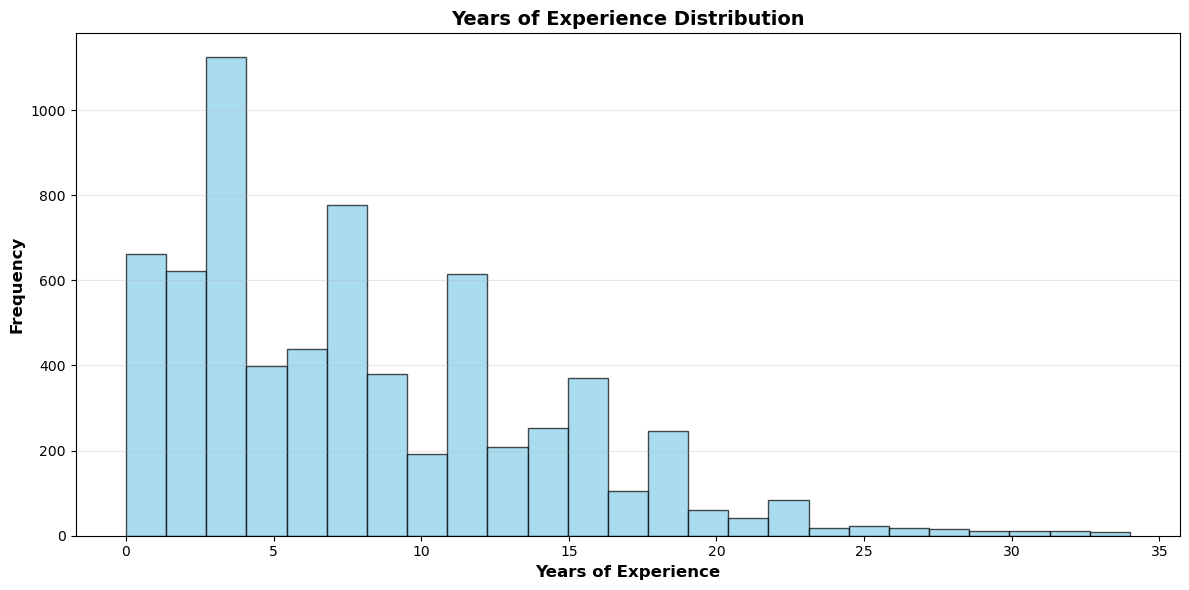

In [16]:
# Experience 
plt.figure(figsize=(12, 6))
plt.hist(df['Years of Experience'], bins=25, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Years of Experience Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Years of Experience', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

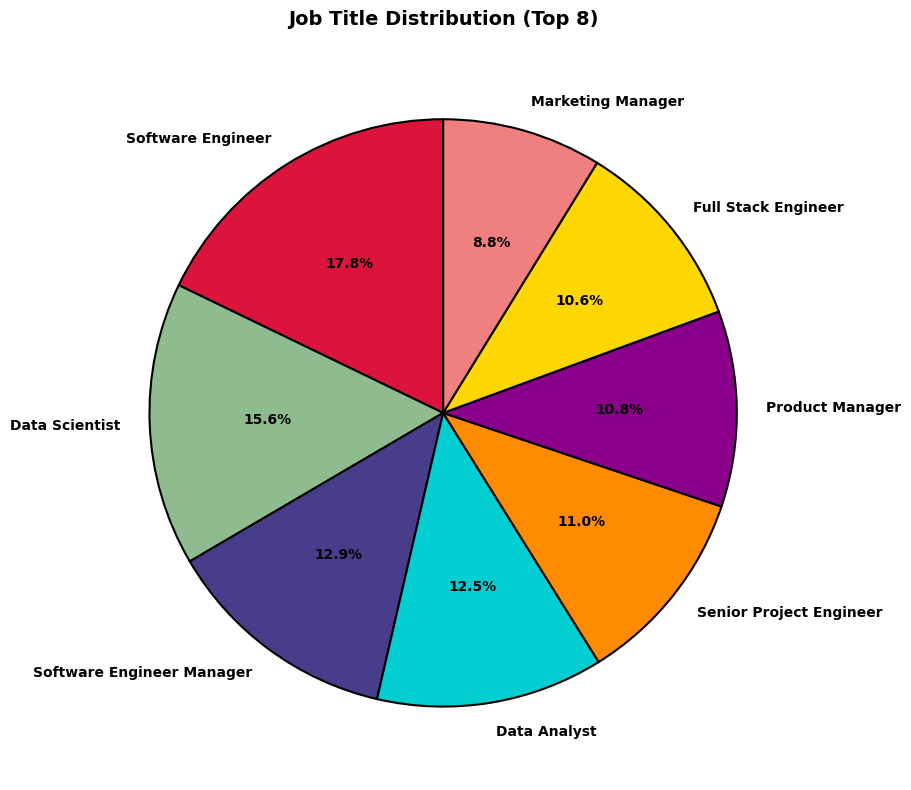

In [17]:
# Job Title Distribution
plt.figure(figsize=(12, 8))

job_counts = df['Job Title'].value_counts().head(8)

colors = ['#DC143C', '#8FBC8F', '#483D8B', '#00CED1', '#FF8C00', '#8B008B', '#FFD700', '#F08080']

plt.pie(job_counts, labels=job_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90, 
        textprops={'fontsize': 10, 'fontweight': 'bold'},
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})

plt.title('Job Title Distribution (Top 8)', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

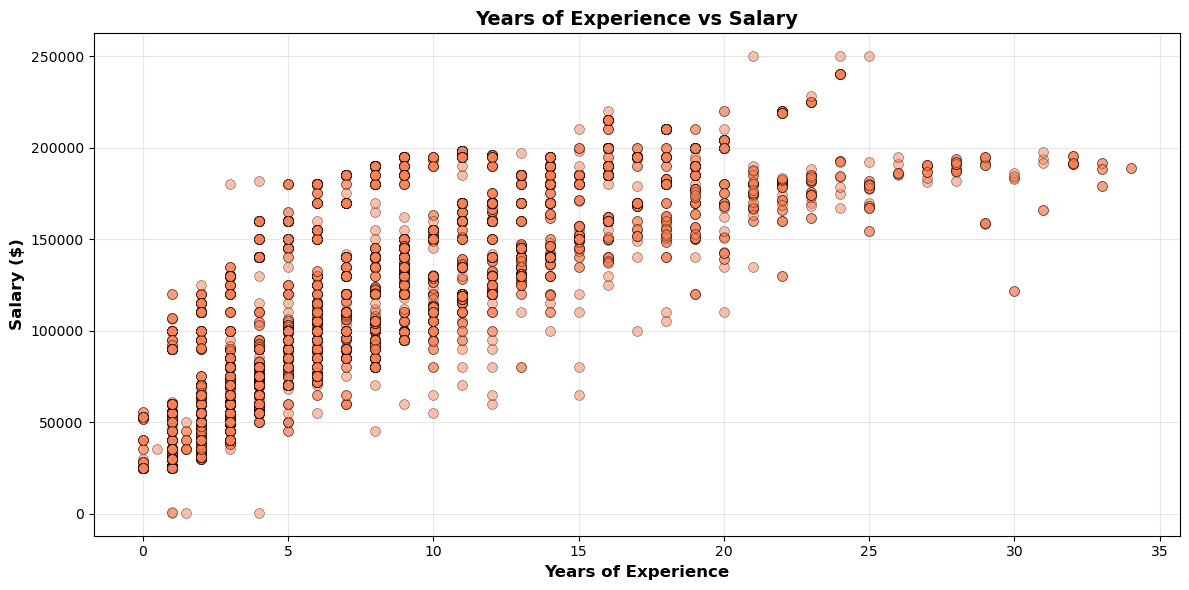

In [18]:
# Years of Experience vs Salary
plt.figure(figsize=(12, 6))
plt.scatter(df['Years of Experience'], df['Salary'], alpha=0.5, s=50, color='coral', edgecolors='black', linewidth=0.5)
plt.title('Years of Experience vs Salary', fontsize=14, fontweight='bold')
plt.xlabel('Years of Experience', fontsize=12, fontweight='bold')
plt.ylabel('Salary ($)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

In [19]:
#Feature Engineering

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6698 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6698 non-null   float64
 1   Gender               6698 non-null   object 
 2   Education Level      6698 non-null   object 
 3   Job Title            6698 non-null   object 
 4   Years of Experience  6698 non-null   float64
 5   Salary               6698 non-null   float64
dtypes: float64(3), object(3)
memory usage: 366.3+ KB


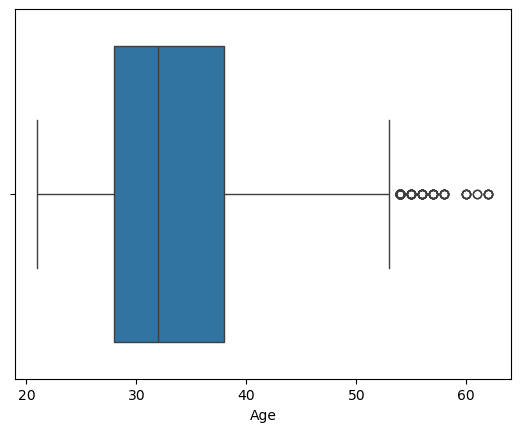

In [21]:
sns.boxplot(x=df['Age']);  

In [22]:
df['Age'].mean()+3*df['Age'].std()

np.float64(56.47037434970878)

In [23]:
df['Gender'].value_counts()

Gender
Male      3671
Female    3013
Other       14
Name: count, dtype: int64

In [24]:
# Other satırlarını sil
df = df[df['Gender'].isin(['Male','Female'])]

# Binary Male=1, Female=0
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})

In [25]:
df['Education Level'].value_counts()

Education Level
Bachelor's Degree    2265
Master's Degree      1570
PhD                  1368
Bachelor's            756
High School           436
Master's              288
phD                     1
Name: count, dtype: int64

In [26]:
mapping = {
    "Bachelor's Degree": "Bachelor",
    "Bachelor's": "Bachelor",
    "Master's Degree": "Master",
    "Master's": "Master",
    "PhD": "PhD",
    "phD": "PhD",
    "High School": "High School"
}

df['Education Level'] = df['Education Level'].map(mapping)

In [27]:
order = {'High School': 1, 'Bachelor': 2, 'Master': 3, 'PhD': 4}
df['Education Level'] = df['Education Level'].map(order)

In [28]:
df['Job Title'].value_counts()

Job Title
Software Engineer                     518
Data Scientist                        453
Software Engineer Manager             376
Data Analyst                          363
Senior Project Engineer               316
                                     ... 
Junior Research Scientist               1
Senior Product Development Manager      1
Junior Social Media Specialist          1
Senior Software Architect               1
Social Media Man                        1
Name: count, Length: 191, dtype: int64

In [29]:
df.groupby('Job Title').size().sort_values(ascending=False)

Job Title
Software Engineer            518
Data Scientist               453
Software Engineer Manager    376
Data Analyst                 363
Senior Project Engineer      316
                            ... 
Technical Writer               1
UX Designer                    1
UX Researcher                  1
VP of Finance                  1
VP of Operations               1
Length: 191, dtype: int64

In [30]:
df['Job Title'].unique()

array(['Software Engineer', 'Data Analyst', 'Senior Manager',
       'Sales Associate', 'Director', 'Marketing Analyst',
       'Product Manager', 'Sales Manager', 'Marketing Coordinator',
       'Senior Scientist', 'Software Developer', 'HR Manager',
       'Financial Analyst', 'Project Manager', 'Customer Service Rep',
       'Operations Manager', 'Marketing Manager', 'Senior Engineer',
       'Data Entry Clerk', 'Sales Director', 'Business Analyst',
       'VP of Operations', 'IT Support', 'Recruiter', 'Financial Manager',
       'Social Media Specialist', 'Software Manager', 'Junior Developer',
       'Senior Consultant', 'Product Designer', 'CEO', 'Accountant',
       'Data Scientist', 'Marketing Specialist', 'Technical Writer',
       'HR Generalist', 'Project Engineer', 'Customer Success Rep',
       'Sales Executive', 'UX Designer', 'Operations Director',
       'Network Engineer', 'Administrative Assistant',
       'Strategy Consultant', 'Copywriter', 'Account Manager',
      

In [31]:
df['Job Title'] = df['Job Title'].str.replace('Juniour', 'Junior')

In [32]:
def categorize_job(job):
    job = job.lower()
    
    if any(x in job for x in ['engineer', 'developer', 'software', 'it', 'qa', 'architect']):
        return 'Tech'
    
    elif any(x in job for x in ['data scientist', 'data analyst', 'data engineer']):
        return 'Data'
    
    elif 'product' in job:
        return 'Product'
    
    elif any(x in job for x in ['business analyst', 'bi']):
        return 'Business'
    
    elif any(x in job for x in ['consultant', 'strategy']):
        return 'Consulting'
    
    elif any(x in job for x in ['account manager']):
        return 'Account Management'
    
    elif any(x in job for x in ['financial', 'accountant', 'finance']):
        return 'Finance'
    
    elif any(x in job for x in ['marketing', 'sales', 'social media', 'content']):
        return 'Marketing & Sales'
    
    elif any(x in job for x in ['ceo', 'cto', 'vp', 'director', 'chief']):
        return 'Executive'
    
    elif any(x in job for x in ['project', 'operations', 'supply chain']):
        return 'Operations'
    
    elif any(x in job for x in ['design', 'ux', 'graphic']):
        return 'Design'
    
    elif any(x in job for x in ['hr', 'human resources', 'recruit']):
        return 'HR'
    
    elif any(x in job for x in ['customer', 'support']):
        return 'Customer Support'
    
    elif any(x in job for x in ['research', 'scientist']):
        return 'Research'
    
    elif any(x in job for x in ['assistant', 'coordinator', 'clerk']):
        return 'Admin'
    
    else:
        return 'Other'
        
df['Job_category'] = df['Job Title'].apply(categorize_job)

In [33]:
df['Job_category'].value_counts()

Job_category
Tech                  2731
Marketing & Sales     1334
Data                   906
Product                475
HR                     348
Executive              223
Finance                206
Operations             178
Research               124
Other                   83
Design                  31
Business                20
Customer Support        13
Admin                    6
Account Management       4
Consulting               2
Name: count, dtype: int64

In [34]:
df[df['Job_category'] == 'Other']['Job Title'].value_counts().head(20)

Job Title
Receptionist                             57
Junior Business Development Associate     7
Delivery Driver                           5
Senior Business Development Manager       4
Senior Manager                            2
Training Specialist                       1
Business Development Manager              1
Business Intelligence Analyst             1
Help Desk Analyst                         1
Senior Training Specialist                1
Office Manager                            1
Public Relations Manager                  1
Senior Account Executive                  1
Name: count, dtype: int64

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6684 entries, 0 to 6703
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6684 non-null   float64
 1   Gender               6684 non-null   int64  
 2   Education Level      6684 non-null   int64  
 3   Job Title            6684 non-null   object 
 4   Years of Experience  6684 non-null   float64
 5   Salary               6684 non-null   float64
 6   Job_category         6684 non-null   object 
dtypes: float64(3), int64(2), object(2)
memory usage: 417.8+ KB


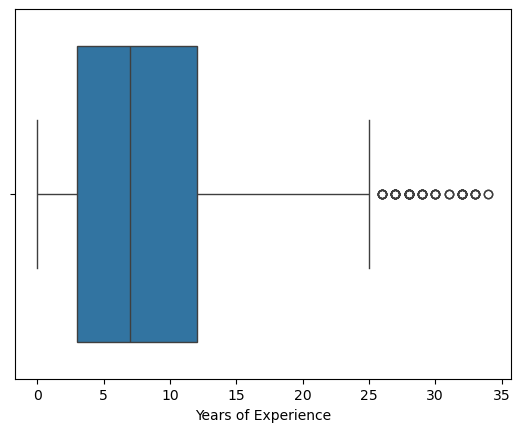

In [36]:
sns.boxplot(x=df['Years of Experience']);  

In [37]:
df['Years of Experience'].mean()+3*df['Years of Experience'].std()

np.float64(26.165637545010586)

In [38]:
#Correlation by Salary
abs(df.corr(numeric_only=True))['Salary'].sort_values(ascending=False) 

Salary                 1.000000
Years of Experience    0.810942
Age                    0.728343
Education Level        0.645444
Gender                 0.127276
Name: Salary, dtype: float64

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6684 entries, 0 to 6703
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6684 non-null   float64
 1   Gender               6684 non-null   int64  
 2   Education Level      6684 non-null   int64  
 3   Job Title            6684 non-null   object 
 4   Years of Experience  6684 non-null   float64
 5   Salary               6684 non-null   float64
 6   Job_category         6684 non-null   object 
dtypes: float64(3), int64(2), object(2)
memory usage: 417.8+ KB


In [40]:
x=df[[
    'Age',
    'Gender',
    'Education Level',
    'Years of Experience',
    'Job_category'
]]

y=df[['Salary']]

In [41]:
x=pd.get_dummies(x, drop_first=True)

In [42]:
from sklearn.model_selection import train_test_split
x_train,x_test, y_train, y_test=train_test_split(x,y, random_state=42, test_size=0.20)

In [43]:
lr=LinearRegression()

In [44]:
model=lr.fit(x_train, y_train)

In [45]:
tahmin=lr.predict(x_test)

In [46]:
r2_score(y_test,tahmin)

0.7617720186533062

In [47]:
mean_squared_error(y_test,tahmin)**0.5

25729.641536436815

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge,Lasso
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import ExtraTreeRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error


def algo_test(x,y):
        #Bütün modelleri tanımlıyorum
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        kn=KNeighborsRegressor()
        dt=DecisionTreeRegressor()
        xgb=XGBRegressor()
       
        
        algos=[L,R,Lass,E,ETR,GBR,kn,dt,xgb]
        algo_names=['Linear','Ridge','Lasso','ElasticNet','Extra Tree','Gradient Boosting','KNeighborsRegressor','Decision Tree','XGBRegressor']
        
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.2,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []
        
        #Hata ve doğruluk oranlarını bir tablo haline getirmek için bir dataframe oluşturuyorum
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)
        
        
        for algo in algos:
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
            

        #result adlı tabloya doğruluk ve hata oranlarımı yerleştiriyorum
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae
        
       #oluşturduğum result tablosunu doğruluk oranına (r2_score) göre sıralayıp dönüyor
        rtable=result.sort_values('R_Squared',ascending=False)
        return rtable

In [49]:
algo_test(x,y)

,R_Squared,RMSE,MAE
XGBRegressor,0.954072,11297.380227,6156.609375
Extra Tree,0.952834,11448.566648,5048.337573
Decision Tree,0.950433,11736.368616,5169.641571
KNeighborsRegressor,0.941537,12746.156659,6265.759910
Gradient Boosting,0.897053,16913.918668,12243.769350
Lasso,0.761792,25728.581771,19804.423359
Linear,0.761772,25729.641536,19811.685607
Ridge,0.761743,25731.222418,19803.132989
ElasticNet,0.714184,28182.594321,22498.066104


In [50]:
comparison = pd.DataFrame({
    'Actual': y_test.values.ravel(),
    'Predicted': tahmin.ravel()
})

comparison.head(20)

,Actual,Predicted
0,88678.0,93342.384531
1,160000.0,153229.484131
2,80000.0,82557.033572
3,120000.0,116159.250479
4,215000.0,161963.251021
5,57000.0,69222.231630
6,120000.0,145518.534655
7,55000.0,63098.263919
8,121120.0,128180.879269
9,126593.0,125424.807554


In [51]:
residuals=y_test-tahmin

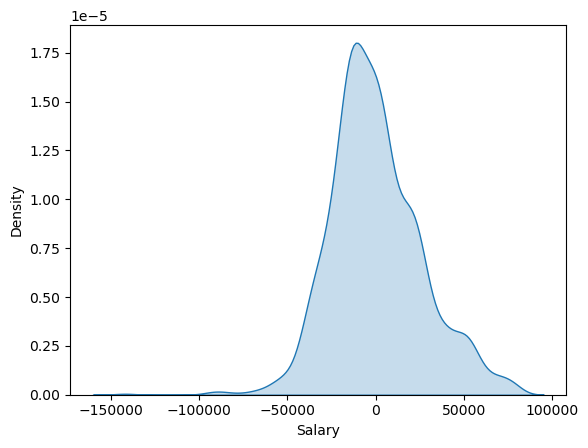

In [52]:
sns.kdeplot(x=residuals['Salary'], fill=True); 

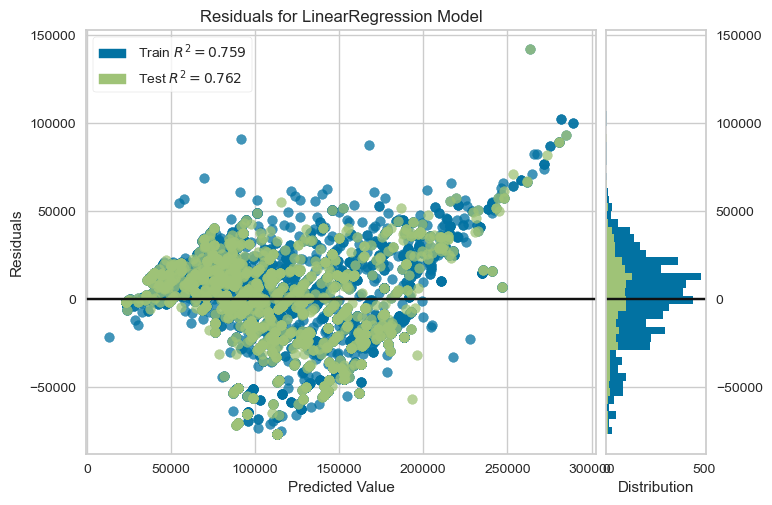

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [53]:
from yellowbrick.regressor import ResidualsPlot
vis = ResidualsPlot(model, force_model=True)
vis.fit(x_train, y_train)
vis.score(x_test, y_test)
vis.show()

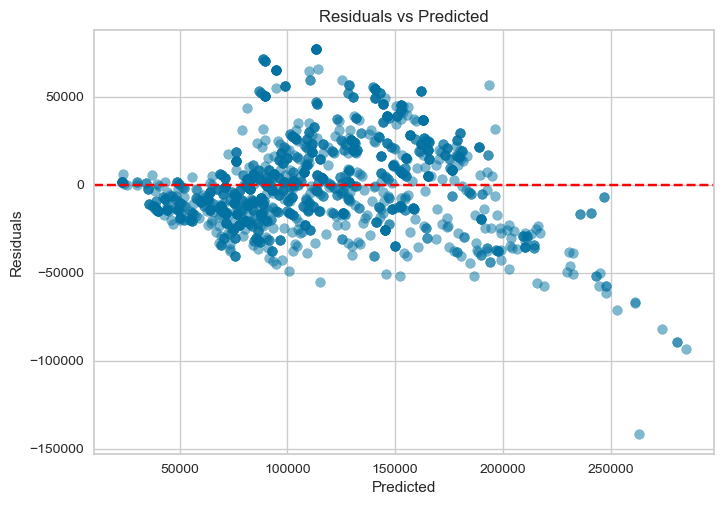

In [54]:
#ya da;
y_pred = model.predict(x_test)
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.show()

In [55]:
from xgboost import XGBRegressor
best_model = XGBRegressor()
best_model.fit(x, y)

#2. Feature listesini al
features = list(x.columns)

# 3. Modeli kaydet (joblib + pkl)
import joblib, pickle

# joblib 
joblib.dump(best_model, 'salary_pred.joblib')

# bundle (model + feature)
with open('salary_pred.pkl', 'wb') as f:
    pickle.dump({
        'model': best_model,
        'features': features
    }, f)

In [56]:
#with Deep Leanring

In [58]:
x=df[[
    'Age',
    'Gender',
    'Education Level',
    'Years of Experience',
    'Job_category'
]]

y=df[['Salary']]

In [59]:
x=pd.get_dummies(x, drop_first=True)

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x = scaler.fit_transform(x)

In [64]:
model=Sequential() 
model.add(Dense(80, activation='relu'))           
model.add(Dense(120, activation='relu'))  
model.add(Dense(64, activation='relu'))  
model.add(Dense(30, activation='relu'))  
model.add(Dense(8, activation='relu'))  
model.add(Dense(1))  #sigmoid yok  

model.compile(loss='mean_squared_error', optimizer='adam')

In [65]:
early_stop=EarlyStopping(monitor='val_loss',patience=10)

In [68]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=30,batch_size=64,callbacks=[early_stop],verbose=1)

Epoch 1/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 770540288.0000 - val_loss: 755200768.0000
Epoch 2/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 757385344.0000 - val_loss: 746742592.0000
Epoch 3/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 750070720.0000 - val_loss: 733452544.0000
Epoch 4/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 740998208.0000 - val_loss: 729795584.0000
Epoch 5/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 733788096.0000 - val_loss: 718500352.0000
Epoch 6/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 730203840.0000 - val_loss: 727569344.0000
Epoch 7/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 724274560.0000 - val_loss: 710393728.0000
Epoch 8/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 719432768.0000 - val_loss: 703672512.0000
Epoch 9/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 718394560.0000 - val_loss: 699932288.0000
Epoch 10/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 711966208.0000 - val_loss: 701917312.0000

In [69]:
tahmin = model.predict(x_test).flatten()

print("R2:", r2_score(y_test, tahmin))
print("RMSE:", np.sqrt(mean_squared_error(y_test, tahmin)))

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
R2: 0.7783823609352112
RMSE: 24816.442291351916


In [70]:
comparison = pd.DataFrame({
    "Gerçek ": y_test.to_numpy().ravel(),
    "Tahmin ": tahmin.ravel()
})

comparison.head(10)

,Gerçek,Tahmin
0,88678.0,87736.179688
1,160000.0,148588.265625
2,80000.0,76874.406250
3,120000.0,116868.617188
4,215000.0,154151.125000
5,57000.0,65549.757812
6,120000.0,150360.828125
7,55000.0,58268.261719
8,121120.0,127071.132812
9,126593.0,123643.273438


🇹🇷 Türkçe
Veri seti üzerinde yapılan ön işleme ve özellik mühendisliği adımlarının ardından çeşitli regresyon modelleri eğitilmiş ve performansları karşılaştırılmıştır. Sonuçlara göre XGBRegressor modeli en yüksek başarıyı göstererek (%95) maaş tahmininde en iyi performansı sağlamıştır.

🇬🇧 English
After performing data preprocessing and feature engineering, multiple regression models were trained and evaluated. According to the results, the XGBRegressor model achieved the best performance (95%), providing the most accurate salary predictions among all models.